In [1]:
import os
import pandas as pd
from datetime import datetime 
import duckdb
import unicodedata
import sys
from pathlib import Path
from kedro.framework.startup import bootstrap_project
from kedro.framework.session import KedroSession

# 1. Move to project root if we are in the notebooks folder
if Path.cwd().name == "notebooks":
    os.chdir("..")

# 2. Initialize Kedro
project_path = Path.cwd()
bootstrap_project(project_path)

# 3. Create session and get catalog
session = KedroSession.create(project_path)
context = session.load_context()
catalog = context.catalog

print(f"✅ Kedro context loaded! Project root: {project_path}")

[04/25/26 15:12:48] INFO     Using                                                                  ]8;id=539038;file://c:\Users\User\miniconda3\envs\central\Lib\site-packages\kedro\framework\project\__init__.py\__init__.py]8;;\:]8;id=271761;file://c:\Users\User\miniconda3\envs\central\Lib\site-packages\kedro\framework\project\__init__.py#269\269]8;;\
                             'c:\Users\User\miniconda3\envs\central\Lib\site-packages\kedro\framewo                
                             rk\project\rich_logging.yml' as logging configuration.                                

[04/25/26 15:12:49] WARNING  c:\Users\User\miniconda3\envs\central\Lib\site-packages\requests\__ini ]8;id=439739;file://c:\Users\User\miniconda3\envs\central\Lib\warnings.py\warnings.py]8;;\:]8;id=651110;file://c:\Users\User\miniconda3\envs\central\Lib\warnings.py#110\110]8;;\
                             t__.py:113: RequestsDependencyWarning: urllib3 (2.6.1) or chardet                     
                             (6.0.0.post1)/charset_normalizer (3.4.4) doesn't match a supported                    
                             version!                                                                              
                               warnings.warn(                                                                      
                                                                                                                   

[04/25/26 15:12:51] INFO     Kedro is sending anonymous usage data with the sole purpose of improving ]8;id=421287;file://c:\Users\User\miniconda3\envs\central\Lib\site-packages\kedro_telemetry\plugin.py\plugin.py]8;;\:]8;id=319019;file://c:\Users\User\miniconda3\envs\central\Lib\site-packages\kedro_telemetry\plugin.py#242\242]8;;\
                             the product. No personal data or IP addresses are stored on our side. To              
                             opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK` environment              
                             variables, or create a `.telemetry` file in the current working                       
                             directory with the contents `consent: false`. To hide this message,                   
                             explicitly grant or deny consent. Read more at                                        
                             https://docs.kedro.org/en/stable/about/telemetry/                                     

✅ Kedro context loaded! Project root: g:\Unidades compartidas\Alianzas\3. Data\CENTRAL\central-perm-flow


In [2]:
sys.path.append(os.path.abspath("src"))
import central_perm_flow.pipelines.data_processing.nodes as nodes_dproc
import central_perm_flow.pipelines.calac_activos_baj_grad.nodes as nodes_abg

In [3]:
central_estados_calac_crt  = catalog.load('central_estados_calac_crt')


[04/25/26 15:13:41] INFO     Loading data from central_estados_calac_crt (ExcelDataset)...     ]8;id=596480;file://c:\Users\User\miniconda3\envs\central\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=246298;file://c:\Users\User\miniconda3\envs\central\Lib\site-packages\kedro\io\data_catalog.py#1048\1048]8;;\

In [5]:
central_estados_calac_crt.columns


Index(['identificacion', 'codigo_sis', 'id_inconcert', 'nombres',
       'usuario_institucional', 'alianza', 'cohorte', 'cohorte_inicial',
       'cohorte_actual', 'nivel', 'nivel_academico', 'programa', 'estado',
       'bloque', 'descuentos', 'fecha_ingreso', 'fecha_de_registro',
       'fecha_de_baja_t', 'fecha_de_baja_d', 'fecha_baja',
       'fecha_de_reingreso', 'fecha_grado', 'fecha_activo', 'tipo_baja',
       'motivo_baja', 'submotivo_baja', 'comentarios', 'periodo_raw',
       'fecha_inicio', 'fecha_fin', 'shifted_fecha_inicio', 'semana',
       'semana_acumulada', 'month', 'mes_academico', 'anio_gregoriano',
       'mes_gregoriano', 'student_journey', 'tipo', 'max_semana_teorica',
       'exito_estudiantil', 'etapa_studen_journey', 'ai', 'di', 'gi', 'engi',
       'ci', 'matricula', 'id_alumno', 'tipo_identidad', 'identidad',
       'primer_nombre', 'segundo_nombre', 'apellido_paterno',
       'apellido_materno', 'genero', 'fecha_nacimiento', 'correo',
       'telefono_movi

In [19]:
central_estados_calac_crt.groupby(['month','genero']).agg({'identificacion':'count',
                                                  'ai':'sum',
                                                  'gi':'sum',
                                                  'ci':'sum',
                                                  'di':'sum'}).reset_index()

,month,genero,identificacion,ai,gi,ci,di
0,0,femenino,1,0,0,0,1
1,0,masculino,2,0,0,0,2
2,1,femenino,39,0,0,0,39
3,1,masculino,31,0,0,0,31
4,2,femenino,218,200,0,0,18
5,2,masculino,196,181,0,0,15
6,3,femenino,7,0,0,0,7
7,3,masculino,2,0,0,0,2
8,4,femenino,229,221,0,0,8
9,4,masculino,214,205,0,0,9


[04/25/26 15:37:26] WARNING  C:\Users\User\AppData\Local\Temp\ipykernel_19744\1033188519.py:45:     ]8;id=560970;file://c:\Users\User\miniconda3\envs\central\Lib\warnings.py\warnings.py]8;;\:]8;id=428148;file://c:\Users\User\miniconda3\envs\central\Lib\warnings.py#110\110]8;;\
                             UserWarning: set_ticklabels() should only be used with a fixed number                 
                             of ticks, i.e. after set_ticks() or using a FixedLocator.                             
                               ax.set_xticklabels()                                                                
                                                                                                                   

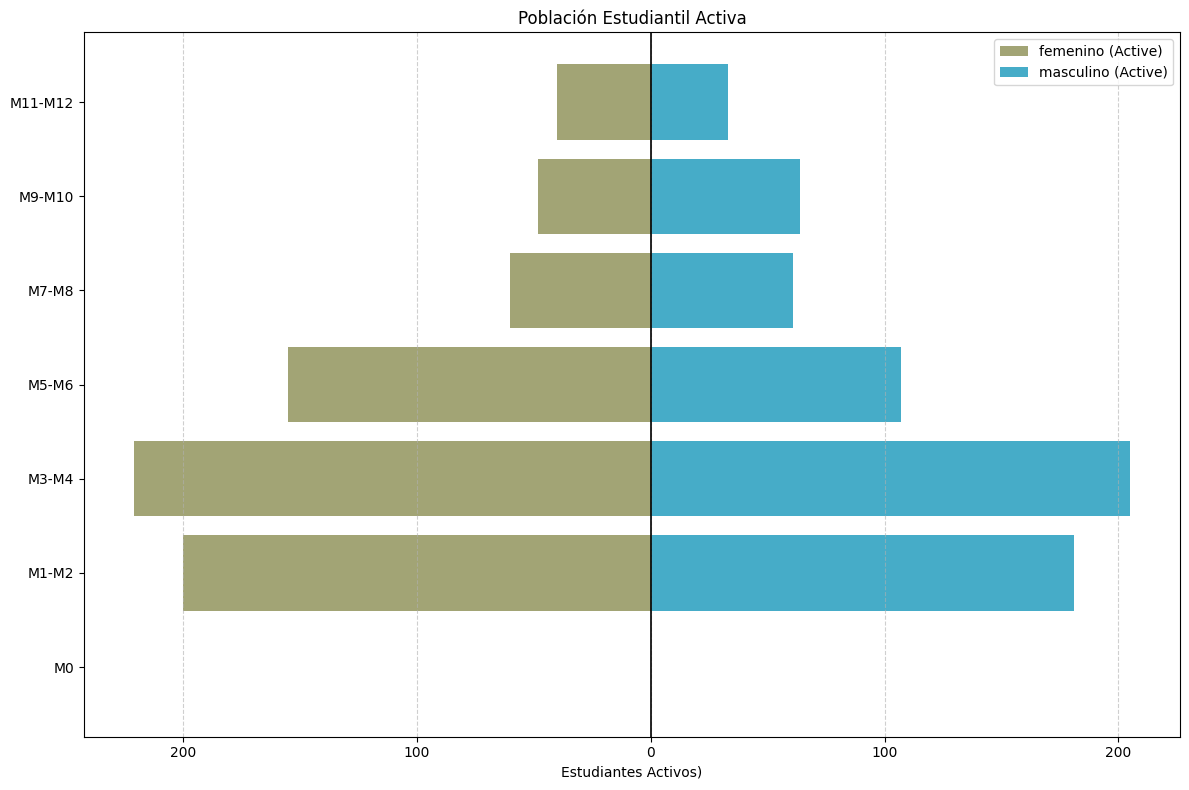

In [26]:
import matplotlib.pyplot as plt
df = central_estados_calac_crt.copy()
# 1. Create the grouping logic
def get_academic_group(month):
    if month == 0:
        return "M0"
    else:
        # Groups: 1-2 -> M1-M2, 3-4 -> M3-M4, etc.
        idx = (month - 1) // 2
        return f"M{2*idx+1}-M{2*idx+2}"

# 2. Apply grouping to your aggregated dataframe
# We use the 'ai' column which represents the active population
df['month_group'] = df['month'].apply(get_academic_group)

# 3. Pivot the data: sum 'ai' by group and gender
pyramid_df = df.groupby(['month_group', 'genero'])['ai'].sum().unstack().fillna(0)

# 4. Ensure M0 is at the bottom (the base)
# We define the order explicitly so M0 is the first index (plotted lowest)
all_possible_groups = ["M0", "M1-M2", "M3-M4", "M5-M6", "M7-M8", "M9-M10", "M11-M12"]
existing_order = [g for g in all_possible_groups if g in pyramid_df.index]
pyramid_df = pyramid_df.reindex(existing_order)

# 5. Visualization
fig, ax = plt.subplots(figsize=(12, 8))

# Identify columns (e.g., 'M' and 'F' or '0' and '1')
genders = pyramid_df.columns
colors = ["#A2A475", "#46ACC8"] # Blue and Red

#"#A2A475" "#46ACC8" "#D8B70A" "#02401B" "#81A88D"

# Plotting: Left side is negative, Right side is positive
ax.barh(pyramid_df.index, -pyramid_df[genders[0]], color=colors[0], label=f"{genders[0]} (Active)")
ax.barh(pyramid_df.index, pyramid_df[genders[1]], color=colors[1], label=f"{genders[1]} (Active)")

# Formatting the axes
ax.axvline(0, color='black', linewidth=1.2) # Center line
ax.set_xlabel('Estudiantes Activos)')
ax.set_title('Población Estudiantil Activa')

# Fix x-axis ticks to show absolute numbers
ticks = ax.get_xticks()
ax.set_xticklabels([int(abs(t)) for t in ticks])

ax.legend(loc='upper right')
ax.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [27]:
import plotly.graph_objects as go
import pandas as pd

# 1. Prepare the data (Using your logic)
df = central_estados_calac_crt.copy()

def get_academic_group(month):
    if month == 0:
        return "M0"
    else:
        idx = (month - 1) // 2
        return f"M{2*idx+1}-M{2*idx+2}"

df['month_group'] = df['month'].apply(get_academic_group)

# Aggregate 'ai' (Active Students)
pyramid_df = df.groupby(['month_group', 'genero'])['ai'].sum().unstack().fillna(0)

# 2. Ensure M0 is at the bottom (Base)
all_possible_groups = ["M0", "M1-M2", "M3-M4", "M5-M6", "M7-M8", "M9-M10", "M11-M12"]
existing_order = [g for g in all_possible_groups if g in pyramid_df.index]
pyramid_df = pyramid_df.reindex(existing_order)

# 3. Create the Plotly Figure
fig = go.Figure()

genders = pyramid_df.columns
# Use your specific colors
colors = ["#A2A475", "#46ACC8"] 

# Left Side (Negative values for the plot logic, but positive in hover)
fig.add_trace(go.Bar(
    y=pyramid_df.index,
    x=-pyramid_df[genders[0]],
    name=str(genders[0]),
    orientation='h',
    marker_color=colors[0],
    hoverinfo='text',
    text=pyramid_df[genders[0]].astype(int),
    hovertemplate="<b>%{y}</b><br>" + str(genders[0]) + ": %{text}<extra></extra>"
))

# Right Side
fig.add_trace(go.Bar(
    y=pyramid_df.index,
    x=pyramid_df[genders[1]],
    name=str(genders[1]),
    orientation='h',
    marker_color=colors[1],
    hoverinfo='text',
    text=pyramid_df[genders[1]].astype(int),
    hovertemplate="<b>%{y}</b><br>" + str(genders[1]) + ": %{text}<extra></extra>"
))

# 4. Update Layout for the "Pyramid" look
fig.update_layout(
    title='Población Estudiantil Activa',
    title_x=0.5,
    barmode='relative', # This aligns them back-to-back
    bargap=0.1,
    xaxis=dict(
        title='Estudiantes Activos',
        tickmode='array',
        # Create ticks that show absolute values
        tickvals=[-max(pyramid_df.max())*1.1, -max(pyramid_df.max())//2, 0, 
                  max(pyramid_df.max())//2, max(pyramid_df.max())*1.1],
        ticktext=[int(abs(x)) for x in [-max(pyramid_df.max())*1.1, -max(pyramid_df.max())//2, 0, 
                                        max(pyramid_df.max())//2, max(pyramid_df.max())*1.1]]
    ),
    yaxis=dict(title='Ciclo Académico'),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    template='plotly_white'
)

fig.show()

In [29]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Prepare Data (same logic as before)
df = central_estados_calac_crt.copy()
def get_academic_group(month):
    if month == 0: return "M0"
    idx = (month - 1) // 2
    return f"M{2*idx+1}-M{2*idx+2}"

df['month_group'] = df['month'].apply(get_academic_group)
pyramid_df = df.groupby(['month_group', 'genero'])['ai'].sum().unstack().fillna(0)

all_possible_groups = ["M0", "M1-M2", "M3-M4", "M5-M6", "M7-M8", "M9-M10", "M11-M12"]
existing_order = [g for g in all_possible_groups if g in pyramid_df.index]
pyramid_df = pyramid_df.reindex(existing_order)

genders = pyramid_df.columns
colors = ["#A2A475", "#46ACC8"]

# 2. Create Subplots: [Left Bar, Center Text, Right Bar]
# Column widths: Left and Right get 45%, Center gets 10%
fig = make_subplots(rows=1, cols=3, 
                    shared_yaxes=True, 
                    column_widths=[0.45, 0.1, 0.45],
                    horizontal_spacing=0.01)

# Left Side (Gender 1)
fig.add_trace(go.Bar(
    y=pyramid_df.index,
    x=-pyramid_df[genders[0]],
    orientation='h',
    name=str(genders[0]),
    marker_color=colors[0],
    text=pyramid_df[genders[0]].astype(int),
    textposition='auto',
    hovertemplate=f"{genders[0]}: %{{text}}<extra></extra>"
), row=1, col=1)

# Right Side (Gender 2)
fig.add_trace(go.Bar(
    y=pyramid_df.index,
    x=pyramid_df[genders[1]],
    orientation='h',
    name=str(genders[1]),
    marker_color=colors[1],
    text=pyramid_df[genders[1]].astype(int),
    textposition='auto',
    hovertemplate=f"{genders[1]}: %{{text}}<extra></extra>"
), row=1, col=3)

# 3. Add Centered Labels (Middle Column)
fig.add_trace(go.Scatter(
    y=pyramid_df.index,
    x=[0] * len(pyramid_df),
    mode="text",
    text=pyramid_df.index,
    textposition="middle center",
    showlegend=False,
    hoverinfo='none'
), row=1, col=2)

# 4. Refine Layout
fig.update_layout(
    title_text="Población Estudiantil Activa",
    title_x=0.5,
    template='plotly_white',
    bargap=0.2,
    xaxis=dict(showticklabels=False, showgrid=False, zeroline=False), # Hide left grid
    xaxis2=dict(showticklabels=False, showgrid=False, zeroline=False), # Hide center grid
    xaxis3=dict(showticklabels=False, showgrid=False, zeroline=False), # Hide right grid
    yaxis=dict(showticklabels=False, showgrid=False, zeroline=False), # Hide Y labels (using center instead)
    legend=dict(orientation="h", y=1.1, x=0.5, xanchor="center")
)

fig.show()